# 3. Probability and Random Walks

- **Objective**: Contrast empirical market distributions with theoretical normal distributions, and simulate multi-path random walks.

## Fat Tails in Financial Data

- Standard models assume returns are normally distributed. Let's overlay a true normal curve over SPY returns to check this assumption.

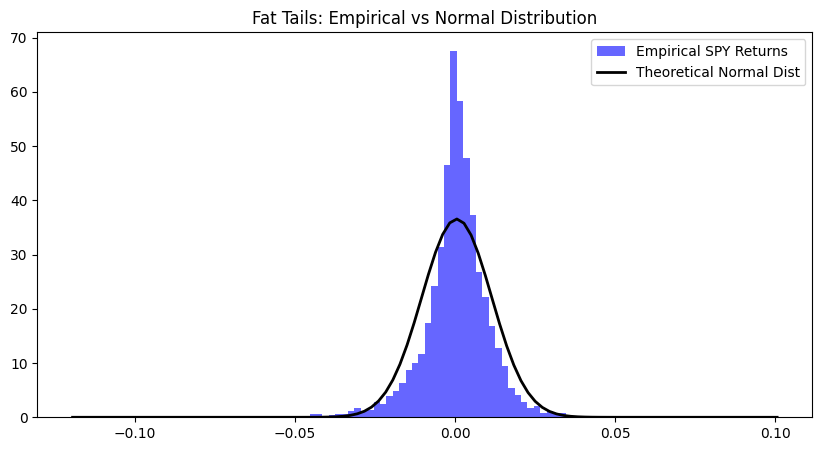

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

spy_returns = yf.Ticker('SPY').history(start='2010-01-01', end='2024-01-01')['Close'].pct_change().dropna()
mu, std = spy_returns.mean(), spy_returns.std()

plt.figure(figsize=(10,5))
plt.hist(spy_returns, bins=100, density=True, alpha=0.6, color='blue', label='Empirical SPY Returns')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label='Theoretical Normal Dist')

plt.title('Fat Tails: Empirical vs Normal Distribution')
plt.legend()
plt.show()

## The Problem with Additive Random Walks

- A basic additive walk: $S_t = S_{t-1} + \text{shock}$.
- Simulating 10 independent additive random walks starting at $100.

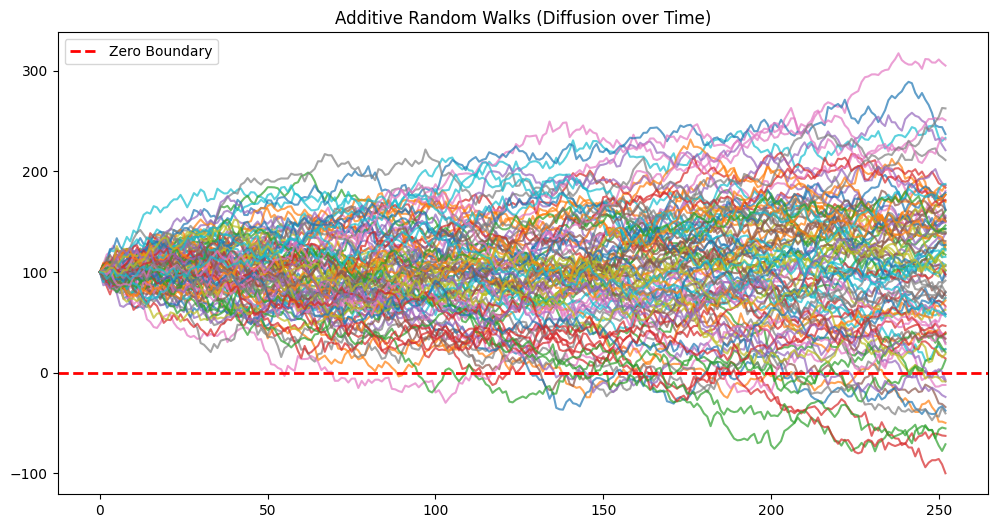

In [3]:
np.random.seed(42)
N_steps = 252
N_paths = 100

shocks = np.random.standard_normal((N_steps, N_paths)) * 5
paths = np.vstack([np.zeros(N_paths), np.cumsum(shocks, axis=0)]) + 100

plt.figure(figsize=(12, 6))
plt.plot(paths, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Boundary')
plt.title('Additive Random Walks (Diffusion over Time)')
plt.legend()
plt.show()

## Questions for Understanding

- Observe the empirical histogram vs the black normal curve. Are extreme market crashes (the far left tail) more or less likely in reality than the normal distribution predicts?
- Why is an additive random walk structurally flawed for modeling stocks that have limited liability (cannot drop below $0)?